## 0. Imports

In [27]:
# ============================================================
# 0. Imports
# ============================================================
import math
import random
from pathlib import Path
from collections import deque
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

## 1. Configuration

In [28]:
# ============================================================
# 1. Configuration
# ============================================================
NODES_CSV = "output/processed_fishtree_nodes.csv"
EDGE_INDEX_NPY = "output/processed_fishtree_edge_index.npy"
EDGE_WEIGHT_NPY = "output/processed_fishtree_edge_weight.npy"

DIST_MATRIX_PATH = "tree_distance_matrix_float32.npy"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model
EMB_DIM = 256
LR = 1e-5
WEIGHT_DECAY = 1e-5

# Training
NUM_STEPS = 200_000
BATCH_SIZE = 256

# Loss
LAMBDA_PAIR = 0.2

TRIPLET_TYPE_WEIGHTS = {
    "same_bin": 1.5,
    "adjacent_bin": 1.25,
    "local_vs_medium": 1.0,
    "medium_vs_far": 0.8,
}

# Best results so far: margin 0.0 everywhere
TRIPLET_TYPE_MARGINS = {
    "same_bin": 0.0,
    "adjacent_bin": 0.0,
    "local_vs_medium": 0.0,
    "medium_vs_far": 0.0,
}

# Equal-width banding
NUM_DISTANCE_BINS = 100
CLIP_DIST_PERCENTILE = 95.0

# Bin-region split over regular bins
LOCAL_BIN_FRACTION = 0.15
MEDIUM_BIN_FRACTION = 0.50

# Sampling mix
SAMPLING_MIX = {
    "same_bin": 0.40,
    "adjacent_bin": 0.25,
    "local_vs_medium": 0.20,
    "medium_vs_far": 0.15,
}

# Distance-matrix preprocessing
DIJKSTRA_BLOCK_SIZE = 256   # tune based on RAM
NUM_WORKERS = max(1, cpu_count() - 1)

# Evaluation
EVAL_NUM_PAIR_SAMPLES = 10000
EVAL_NUM_ANCHORS = 200
EVAL_CANDIDATE_SIZE = 2000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)
print("CPU workers:", NUM_WORKERS)

Using device: cuda
CPU workers: 27


## 2. Load tree files

In [29]:
# ============================================================
# 2. Load tree files
# ============================================================
nodes_df = pd.read_csv(NODES_CSV)
edge_index = np.load(EDGE_INDEX_NPY)
edge_weight = np.load(EDGE_WEIGHT_NPY)

num_nodes = len(nodes_df)

print("num_nodes:", num_nodes)
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)

nodes_df.head()

num_nodes: 22919
edge_index shape: (2, 45836)
edge_weight shape: (45836,)


,node_id,node_name,is_leaf,species
0,0,internal_0,False,NaN
1,1,internal_1,False,NaN
2,2,internal_2,False,NaN
3,3,internal_3,False,NaN
4,4,internal_4,False,NaN


## 3. Build sparse graph once

In [30]:
# ============================================================
# 3. Build sparse graph
# ============================================================
def build_sparse_graph(edge_index, edge_weight, num_nodes):
    src = edge_index[0].astype(np.int64)
    dst = edge_index[1].astype(np.int64)
    data = edge_weight.astype(np.float64)  # scipy dijkstra returns float64 anyway

    graph = csr_matrix((data, (src, dst)), shape=(num_nodes, num_nodes))
    return graph

graph = build_sparse_graph(edge_index, edge_weight, num_nodes)
print(graph)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45836 stored elements and shape (22919, 22919)>
  Coords	Values
  (0, 1)	0.1449403315782547
  (0, 22896)	1.0290260314941406
  (1, 0)	0.1449403315782547
  (1, 2)	0.1516873687505722
  (1, 22845)	0.42339950799942017
  (2, 1)	0.1516873687505722
  (2, 3)	0.38424384593963623
  (2, 22830)	0.255990594625473
  (3, 2)	0.38424384593963623
  (3, 4)	0.08714011311531067
  (3, 22401)	0.1532358080148697
  (4, 3)	0.08714011311531067
  (4, 5)	0.21228080987930298
  (4, 22204)	0.12637940049171448
  (5, 4)	0.21228080987930298
  (5, 6)	0.10065711289644241
  (5, 15175)	0.09478769451379776
  (6, 5)	0.10065711289644241
  (6, 7)	0.12997013330459595
  (6, 15174)	0.850622832775116
  (7, 6)	0.12997013330459595
  (7, 8)	0.06234422326087952
  (7, 14957)	0.07460571080446243
  (8, 7)	0.06234422326087952
  (8, 9)	0.06394698470830917
  :	:
  (22902, 22906)	0.08762970566749573
  (22903, 22902)	0.016438767313957214
  (22903, 22904)	0.06075504422187805
  (22903,

## 4. Build or load the dense float32 distance matrix

In [31]:
# ============================================================
# 4. Build / load dense distance matrix
# ============================================================
def build_distance_matrix_blockwise(
    graph,
    num_nodes,
    out_path,
    block_size=256,
):
    """
    Build full dense node-node distance matrix as float32 and save to disk.
    Uses scipy sparse dijkstra in source-row blocks.

    Output:
        npy file of shape (num_nodes, num_nodes), dtype=float32
    """
    out_path = Path(out_path)

    # Allocate writable memmap-backed npy
    dist_mem = np.lib.format.open_memmap(
        out_path,
        mode="w+",
        dtype=np.float32,
        shape=(num_nodes, num_nodes),
    )

    row_starts = list(range(0, num_nodes, block_size))

    for start in tqdm(row_starts, desc="Computing distance matrix blocks"):
        end = min(start + block_size, num_nodes)
        indices = np.arange(start, end, dtype=np.int64)

        # distances shape: [block_size, num_nodes], float64
        block = dijkstra(
            csgraph=graph,
            directed=False,
            indices=indices,
            return_predecessors=False,
        )

        dist_mem[start:end, :] = block.astype(np.float32)

    dist_mem.flush()
    del dist_mem

    return out_path

In [32]:
dist_matrix_path = Path(DIST_MATRIX_PATH)

if dist_matrix_path.exists():
    print("Distance matrix already exists on disk.")
else:
    print("Building dense distance matrix...")
    build_distance_matrix_blockwise(
        graph=graph,
        num_nodes=num_nodes,
        out_path=dist_matrix_path,
        block_size=DIJKSTRA_BLOCK_SIZE,
    )
    print(f"Saved distance matrix to: {dist_matrix_path}")

Distance matrix already exists on disk.


In [33]:
# Fastest if you have enough RAM:
D = np.load(dist_matrix_path)

# If you ever want lower RAM pressure instead, use:
# D = np.load(dist_matrix_path, mmap_mode="r")

print("D shape:", D.shape, "dtype:", D.dtype)

D shape: (22919, 22919) dtype: float32


## 5. Node-type masks

In [34]:
# ============================================================
# 5. Node-type masks
# ============================================================
is_leaf = nodes_df["is_leaf"].astype(bool).to_numpy()
leaf_ids = np.where(is_leaf)[0]
internal_ids = np.where(~is_leaf)[0]

print("num leaves:", len(leaf_ids))
print("num internal:", len(internal_ids))

num leaves: 11460
num internal: 11459


## 6. Estimate tau from the dense matrix

In [35]:
# ============================================================
# 6. Estimate tau
# ============================================================
def estimate_tau_from_dense(D, num_samples=100_000):
    n = D.shape[0]
    dists = []

    for _ in range(num_samples):
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v:
            continue
        dists.append(float(D[u, v]))

    return float(np.median(dists))

tau = estimate_tau_from_dense(D)
print("Estimated tau:", tau)

Estimated tau: 2.2386558055877686


## 7. Estimate clipping distance for equal-width bins

In [36]:
# ============================================================
# 7. Estimate clip distance
# ============================================================
def sample_distance_distribution_from_dense(D, num_samples=100_000):
    n = D.shape[0]
    dists = []

    for _ in range(num_samples):
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v:
            continue
        dists.append(float(D[u, v]))

    return np.array(dists, dtype=np.float32)

dist_samples = sample_distance_distribution_from_dense(D)
clip_distance = float(np.percentile(dist_samples, CLIP_DIST_PERCENTILE))

print("Distance percentiles:")
for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"p{q:2d} = {np.percentile(dist_samples, q):.4f}")

print("clip_distance:", clip_distance)

Distance percentiles:
p 1 = 0.3590
p 5 = 0.7260
p10 = 0.9322
p25 = 1.3589
p50 = 2.2494
p75 = 3.0132
p90 = 3.3131
p95 = 3.5216
p99 = 4.0144
clip_distance: 3.521637439727783


## 8. Build a compact in-memory band index

In [37]:
# ============================================================
# 8. Build compact band index
# ============================================================
def build_compact_band_index_from_dense(
    D,
    clip_distance,
    num_regular_bins,
):
    """
    Build compact band index from dense distance matrix.

    Returns
    -------
    dict with:
      sorted_ids  : np.ndarray [N, N-1] int32
      bin_offsets : np.ndarray [N, num_total_bins + 1] int32
      bin_edges   : np.ndarray [num_regular_bins + 1] float32
      clip_distance, num_regular_bins, num_total_bins
    """
    n = D.shape[0]
    num_total_bins = num_regular_bins + 1  # + overflow

    sorted_ids = np.empty((n, n - 1), dtype=np.int32)
    bin_offsets = np.empty((n, num_total_bins + 1), dtype=np.int32)

    bin_edges = np.linspace(0.0, clip_distance, num_regular_bins + 1, dtype=np.float32)

    for u in tqdm(range(n), desc="Building compact band index"):
        row = D[u]

        # full sort, then remove self
        order = np.argsort(row, kind="stable")
        order = order[order != u]

        sorted_ids[u, :] = order.astype(np.int32, copy=False)

        sorted_dists = row[order]

        # regular bins: positions where distance <= upper edge
        # searchsorted returns slice end positions
        ends = np.searchsorted(sorted_dists, bin_edges[1:], side="right").astype(np.int32)

        # offsets: [0, end_bin0, end_bin1, ..., end_last_regular, n-1]
        bin_offsets[u, 0] = 0
        bin_offsets[u, 1:num_regular_bins + 1] = ends
        bin_offsets[u, num_total_bins] = n - 1

    return {
        "sorted_ids": sorted_ids,
        "bin_offsets": bin_offsets,
        "bin_edges": bin_edges,
        "clip_distance": float(clip_distance),
        "num_regular_bins": int(num_regular_bins),
        "num_total_bins": int(num_total_bins),
    }

In [38]:
band_index = build_compact_band_index_from_dense(
    D=D,
    clip_distance=clip_distance,
    num_regular_bins=NUM_DISTANCE_BINS,
)

sorted_ids = band_index["sorted_ids"]
bin_offsets = band_index["bin_offsets"]

print("sorted_ids shape:", sorted_ids.shape, sorted_ids.dtype)
print("bin_offsets shape:", bin_offsets.shape, bin_offsets.dtype)

Building compact band index:   0%|          | 0/22919 [00:00<?, ?it/s]

Building compact band index: 100%|██████████| 22919/22919 [00:18<00:00, 1239.95it/s]

sorted_ids shape: (22919, 22918) int32
bin_offsets shape: (22919, 102) int32


## 9. Inspect approximate memory footprint

In [39]:
# ============================================================
# 9. Memory footprint
# ============================================================
def bytes_to_gb(x):
    return x / (1024 ** 3)

print("Distance matrix GB:", bytes_to_gb(D.nbytes))
print("sorted_ids GB:", bytes_to_gb(sorted_ids.nbytes))
print("bin_offsets GB:", bytes_to_gb(bin_offsets.nbytes))
print("Total GB:", bytes_to_gb(D.nbytes + sorted_ids.nbytes + bin_offsets.nbytes))

Distance matrix GB: 1.9568225778639317
sorted_ids GB: 1.9567371979355812
bin_offsets GB: 0.008708752691745758
Total GB: 3.9222685284912586


## 10. Define bin regions

In [40]:
# ============================================================
# 10. Bin regions
# ============================================================
num_regular_bins = band_index["num_regular_bins"]
overflow_bin = num_regular_bins

local_end = max(1, int(num_regular_bins * LOCAL_BIN_FRACTION))
medium_end = max(local_end + 1, int(num_regular_bins * MEDIUM_BIN_FRACTION))

local_bins = list(range(0, local_end))
medium_bins = list(range(local_end, medium_end))
far_bins = list(range(medium_end, num_regular_bins))

print("num_regular_bins:", num_regular_bins)
print("local bins:", (local_bins[0], local_bins[-1]) if local_bins else None)
print("medium bins:", (medium_bins[0], medium_bins[-1]) if medium_bins else None)
print("far bins:", (far_bins[0], far_bins[-1]) if far_bins else None)
print("overflow bin:", overflow_bin)

num_regular_bins: 100
local bins: (0, 14)
medium bins: (15, 49)
far bins: (50, 99)
overflow bin: 100


## 11. Model

In [41]:
# ============================================================
# 11. Model
# ============================================================
class NodeEmbeddingModel(nn.Module):
    def __init__(self, num_nodes, emb_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, emb_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, node_ids):
        z = self.embedding(node_ids)
        z = F.normalize(z, p=2, dim=-1)
        return z

    def get_all_embeddings(self):
        z = self.embedding.weight
        return F.normalize(z, p=2, dim=-1)

## 12. Multi-scale sampler using dense matrix + compact band index

In [42]:
# ============================================================
# 12. Multi-scale sampler
# ============================================================
class MultiScaleDenseBandSampler:
    def __init__(
        self,
        D,
        sorted_ids,
        bin_offsets,
        local_bins,
        medium_bins,
        far_bins,
        overflow_bin,
        sampling_mix,
    ):
        self.D = D
        self.sorted_ids = sorted_ids
        self.bin_offsets = bin_offsets

        self.num_nodes = D.shape[0]
        self.num_regular_bins = overflow_bin
        self.num_total_bins = overflow_bin + 1
        self.overflow_bin = overflow_bin

        self.local_bins = local_bins
        self.medium_bins = medium_bins
        self.far_bins = far_bins

        self.triplet_type_names = list(sampling_mix.keys())
        self.triplet_type_probs = np.array(list(sampling_mix.values()), dtype=np.float64)
        self.triplet_type_probs /= self.triplet_type_probs.sum()

        # bias toward smaller bins for positive selection
        self.regular_bin_probs = np.array(
            [1.0 / (1.0 + b) for b in range(self.num_regular_bins)],
            dtype=np.float64,
        )
        self.regular_bin_probs /= self.regular_bin_probs.sum()

    def dist(self, u, v):
        return float(self.D[u, v])

    def _choose_anchor(self):
        return random.randrange(self.num_nodes)

    def _bin_slice(self, anchor, b):
        start = int(self.bin_offsets[anchor, b])
        end = int(self.bin_offsets[anchor, b + 1])
        return start, end

    def _bin_size(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        return end - start

    def _sample_nonempty_bin(self, anchor, candidate_bins, weighted=False):
        valid = [b for b in candidate_bins if self._bin_size(anchor, b) > 0]
        if not valid:
            return None

        if weighted:
            weights = np.array(
                [self.regular_bin_probs[b] if b < self.num_regular_bins else 1e-6 for b in valid],
                dtype=np.float64,
            )
            if weights.sum() == 0:
                weights = np.ones(len(valid), dtype=np.float64)
            weights /= weights.sum()
            return int(np.random.choice(valid, p=weights))

        return int(random.choice(valid))

    def _sample_from_bin_uniform(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        if end <= start:
            return None

        pos = random.randrange(start, end)
        node = int(self.sorted_ids[anchor, pos])
        d = float(self.D[anchor, node])
        return node, d, pos

    def _sample_same_bin_ordered_pair(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        size = end - start
        if size < 2:
            return None

        i = random.randrange(start, end - 1)
        j = random.randrange(i + 1, end)

        v = int(self.sorted_ids[anchor, i])
        w = int(self.sorted_ids[anchor, j])

        d_uv = float(self.D[anchor, v])
        d_uw = float(self.D[anchor, w])

        if d_uv < d_uw:
            return v, w, d_uv, d_uw

        # stable fallback
        if d_uv > d_uw:
            return w, v, d_uw, d_uv

        return None

    def _sample_adjacent_bin_pair(self, anchor):
        valid_i = []
        for i in range(self.num_regular_bins - 1):
            if self._bin_size(anchor, i) > 0 and self._bin_size(anchor, i + 1) > 0:
                valid_i.append(i)

        if not valid_i:
            return None

        weights = np.array([self.regular_bin_probs[i] for i in valid_i], dtype=np.float64)
        weights /= weights.sum()
        i = int(np.random.choice(valid_i, p=weights))

        pos = self._sample_from_bin_uniform(anchor, i)
        neg = self._sample_from_bin_uniform(anchor, i + 1)
        if pos is None or neg is None:
            return None

        v, d_uv, _ = pos
        w, d_uw, _ = neg

        if d_uv < d_uw:
            return v, w, d_uv, d_uw
        elif d_uv > d_uw:
            return w, v, d_uw, d_uv
        return None

    def _sample_cross_region_pair(self, anchor, pos_bins, neg_bins, pos_weighted=True, neg_weighted=False):
        pos_bin = self._sample_nonempty_bin(anchor, pos_bins, weighted=pos_weighted)
        if pos_bin is None:
            return None

        valid_neg_bins = [b for b in neg_bins if b >= pos_bin and self._bin_size(anchor, b) > 0]
        if not valid_neg_bins:
            return None

        neg_bin = self._sample_nonempty_bin(anchor, valid_neg_bins, weighted=neg_weighted)
        if neg_bin is None:
            return None

        if neg_bin == pos_bin:
            return self._sample_same_bin_ordered_pair(anchor, pos_bin)

        pos = self._sample_from_bin_uniform(anchor, pos_bin)
        neg = self._sample_from_bin_uniform(anchor, neg_bin)
        if pos is None or neg is None:
            return None

        v, d_uv, _ = pos
        w, d_uw, _ = neg

        if d_uv < d_uw:
            return v, w, d_uv, d_uw
        elif d_uv > d_uw:
            return w, v, d_uw, d_uv
        return None

    def sample_triplet(self, max_anchor_tries=100):
        for _ in range(max_anchor_tries):
            anchor = self._choose_anchor()
            triplet_type = np.random.choice(self.triplet_type_names, p=self.triplet_type_probs)

            if triplet_type == "same_bin":
                b = self._sample_nonempty_bin(anchor, self.local_bins + self.medium_bins, weighted=True)
                if b is None:
                    continue
                pair = self._sample_same_bin_ordered_pair(anchor, b)
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair

            elif triplet_type == "adjacent_bin":
                pair = self._sample_adjacent_bin_pair(anchor)
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair

            elif triplet_type == "local_vs_medium":
                pair = self._sample_cross_region_pair(
                    anchor,
                    pos_bins=self.local_bins,
                    neg_bins=self.medium_bins + self.far_bins + [self.overflow_bin],
                    pos_weighted=True,
                    neg_weighted=False,
                )
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair

            elif triplet_type == "medium_vs_far":
                pair = self._sample_cross_region_pair(
                    anchor,
                    pos_bins=self.medium_bins if self.medium_bins else self.local_bins,
                    neg_bins=self.far_bins + [self.overflow_bin],
                    pos_weighted=False,
                    neg_weighted=False,
                )
                if pair is None:
                    continue
                v, w, d_uv, d_uw = pair

            else:
                continue

            return {
                "anchor": anchor,
                "pos": v,
                "neg": w,
                "d_pos": d_uv,
                "d_neg": d_uw,
                "triplet_type": triplet_type,
            }

        return None

    def sample_batch(self, batch_size):
        batch = []
        while len(batch) < batch_size:
            t = self.sample_triplet()
            if t is not None:
                batch.append(t)
        return batch

In [43]:
sampler = MultiScaleDenseBandSampler(
    D=D,
    sorted_ids=sorted_ids,
    bin_offsets=bin_offsets,
    local_bins=local_bins,
    medium_bins=medium_bins,
    far_bins=far_bins,
    overflow_bin=overflow_bin,
    sampling_mix=SAMPLING_MIX,
)

## 13. Loss

In [44]:
# ============================================================
# 13. Loss
# ============================================================
def cosine_sim(a, b):
    return (a * b).sum(dim=-1)


def pair_target_from_distance(d, tau):
    return torch.exp(-d / tau)


def distance_weight(d):
    return 1.0 / (1.0 + d)


def compute_loss(
    model,
    batch_triplets,
    tau,
    lambda_pair=0.2,
    device="cpu",
):
    u = torch.tensor([t["anchor"] for t in batch_triplets], dtype=torch.long, device=device)
    v = torch.tensor([t["pos"] for t in batch_triplets], dtype=torch.long, device=device)
    w = torch.tensor([t["neg"] for t in batch_triplets], dtype=torch.long, device=device)

    d_uv = torch.tensor([t["d_pos"] for t in batch_triplets], dtype=torch.float32, device=device)
    d_uw = torch.tensor([t["d_neg"] for t in batch_triplets], dtype=torch.float32, device=device)

    triplet_weights = torch.tensor(
        [TRIPLET_TYPE_WEIGHTS[t["triplet_type"]] for t in batch_triplets],
        dtype=torch.float32,
        device=device,
    )
    triplet_margins = torch.tensor(
        [TRIPLET_TYPE_MARGINS[t["triplet_type"]] for t in batch_triplets],
        dtype=torch.float32,
        device=device,
    )

    z_u = model(u)
    z_v = model(v)
    z_w = model(w)

    s_uv = cosine_sim(z_u, z_v)
    s_uw = cosine_sim(z_u, z_w)

    triplet_terms = F.relu(triplet_margins - s_uv + s_uw)
    triplet_loss = (triplet_weights * triplet_terms).mean()

    target_uv = pair_target_from_distance(d_uv, tau)
    target_uw = pair_target_from_distance(d_uw, tau)

    weight_uv = distance_weight(d_uv)
    weight_uw = distance_weight(d_uw)

    pair_loss = (
        (weight_uv * (s_uv - target_uv) ** 2).mean()
        + (weight_uw * (s_uw - target_uw) ** 2).mean()
    )

    total_loss = triplet_loss + lambda_pair * pair_loss

    stats = {
        "loss": float(total_loss.item()),
        "triplet_loss": float(triplet_loss.item()),
        "pair_loss": float(pair_loss.item()),
        "mean_sim_pos": float(s_uv.mean().item()),
        "mean_sim_neg": float(s_uw.mean().item()),
        "mean_d_pos": float(d_uv.mean().item()),
        "mean_d_neg": float(d_uw.mean().item()),
    }

    for name in TRIPLET_TYPE_WEIGHTS:
        mask = torch.tensor(
            [t["triplet_type"] == name for t in batch_triplets],
            dtype=torch.bool,
            device=device,
        )
        stats[f"count_{name}"] = int(mask.sum().item())
        if mask.any():
            stats[f"triplet_term_{name}"] = float(triplet_terms[mask].mean().item())
        else:
            stats[f"triplet_term_{name}"] = float("nan")

    return total_loss, stats

## 14. Train

In [45]:
# ============================================================
# 14. Training
# ============================================================
model = NodeEmbeddingModel(num_nodes=num_nodes, emb_dim=EMB_DIM).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []

for step in range(NUM_STEPS):
    batch_triplets = sampler.sample_batch(BATCH_SIZE)

    optimizer.zero_grad()
    loss, stats = compute_loss(
        model=model,
        batch_triplets=batch_triplets,
        tau=tau,
        lambda_pair=LAMBDA_PAIR,
        device=DEVICE,
    )
    loss.backward()
    optimizer.step()

    history.append(stats)

    if step % 200 == 0:
        print(
            f"step={step:6d}  "
            f"loss={stats['loss']:.4f}  "
            f"triplet={stats['triplet_loss']:.4f}  "
            f"pair={stats['pair_loss']:.4f}  "
            f"d_pos={stats['mean_d_pos']:.4f}  "
            f"d_neg={stats['mean_d_neg']:.4f}"
        )

step=     0  loss=0.2105  triplet=0.0395  pair=0.8549  d_pos=0.6422  d_neg=1.2935
step=   200  loss=0.2105  triplet=0.0393  pair=0.8562  d_pos=0.6074  d_neg=1.2832
step=   400  loss=0.2253  triplet=0.0417  pair=0.9179  d_pos=0.5999  d_neg=1.2127
step=   600  loss=0.2157  triplet=0.0374  pair=0.8914  d_pos=0.5876  d_neg=1.2787
step=   800  loss=0.2310  triplet=0.0380  pair=0.9650  d_pos=0.5210  d_neg=1.1555
step=  1000  loss=0.2099  triplet=0.0378  pair=0.8606  d_pos=0.5882  d_neg=1.2830
step=  1200  loss=0.2263  triplet=0.0434  pair=0.9147  d_pos=0.5890  d_neg=1.2061
step=  1400  loss=0.2055  triplet=0.0372  pair=0.8416  d_pos=0.6442  d_neg=1.3230
step=  1600  loss=0.2261  triplet=0.0435  pair=0.9128  d_pos=0.5362  d_neg=1.1216
step=  1800  loss=0.2280  triplet=0.0425  pair=0.9273  d_pos=0.5467  d_neg=1.1716
step=  2000  loss=0.2101  triplet=0.0380  pair=0.8605  d_pos=0.6159  d_neg=1.2247
step=  2200  loss=0.2243  triplet=0.0432  pair=0.9054  d_pos=0.5601  d_neg=1.2392
step=  2400  los

## 15. Plot training curves

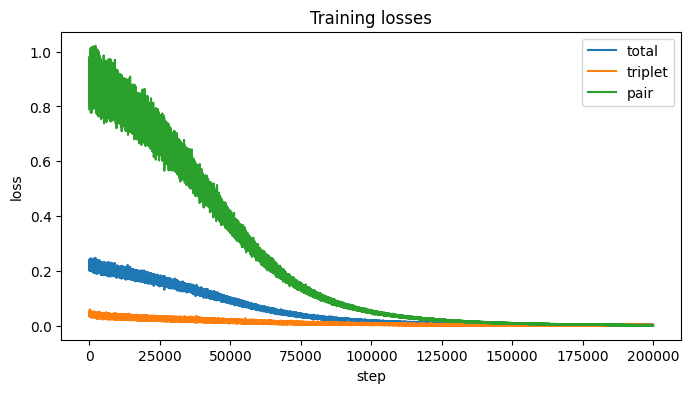

In [46]:
# ============================================================
# 15. Plot training curves
# ============================================================
losses = [x["loss"] for x in history]
triplet_losses = [x["triplet_loss"] for x in history]
pair_losses = [x["pair_loss"] for x in history]

plt.figure(figsize=(8, 4))
plt.plot(losses, label="total")
plt.plot(triplet_losses, label="triplet")
plt.plot(pair_losses, label="pair")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Training losses")
plt.show()

## 17. Local pair correlation

In [47]:
# ============================================================
# 17. Local pair correlation
# ============================================================
@torch.no_grad()
def evaluate_local_pair_correlation_dense(
    model,
    D,
    node_ids_a,
    node_ids_b,
    max_tree_dist,
    num_samples=5000,
    device="cpu",
    max_tries=200000,
):
    model.eval()

    dists = []
    neg_sims = []
    tries = 0

    while len(dists) < num_samples and tries < max_tries:
        tries += 1

        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d = float(D[u, v])
        if d > max_tree_dist:
            continue

        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        sim = float((z[0] * z[1]).sum().item())

        dists.append(d)
        neg_sims.append(-sim)

    if len(dists) < 10:
        return {
            "num_pairs": len(dists),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    return {
        "num_pairs": len(dists),
        "spearman": float(spearmanr(dists, neg_sims).correlation),
        "pearson": float(pearsonr(dists, neg_sims)[0]),
    }

In [53]:
for threshold in [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]:
    result = evaluate_local_pair_correlation_dense(
        model,
        D,
        leaf_ids,
        leaf_ids,
        max_tree_dist=threshold,
        num_samples=3000,
        device=DEVICE,
    )
    print(f"Local leaf-leaf, max_tree_dist={threshold}: {result}")

Local leaf-leaf, max_tree_dist=0.1: {'num_pairs': 134, 'spearman': 0.7984064639209966, 'pearson': 0.8008707344358641}
Local leaf-leaf, max_tree_dist=0.2: {'num_pairs': 441, 'spearman': 0.9387785883584203, 'pearson': 0.9397745803345365}
Local leaf-leaf, max_tree_dist=0.5: {'num_pairs': 2633, 'spearman': 0.9746419450689507, 'pearson': 0.9785180357668012}
Local leaf-leaf, max_tree_dist=1.0: {'num_pairs': 3000, 'spearman': 0.9506106184903401, 'pearson': 0.9786492284609436}
Local leaf-leaf, max_tree_dist=2.0: {'num_pairs': 3000, 'spearman': 0.9782070864626111, 'pearson': 0.9784957209961658}
Local leaf-leaf, max_tree_dist=5.0: {'num_pairs': 3000, 'spearman': 0.954403389155932, 'pearson': 0.972086584744021}
Local leaf-leaf, max_tree_dist=10.0: {'num_pairs': 3000, 'spearman': 0.9516514888501654, 'pearson': 0.9707696806933508}


## 18. Recall@k

In [49]:
# ============================================================
# 18. Recall@k
# ============================================================
@torch.no_grad()
def cosine_similarity_to_candidates(model, anchor, candidates, device="cpu"):
    model.eval()

    nodes = torch.tensor([anchor] + candidates, dtype=torch.long, device=device)
    z = model(nodes)

    z_anchor = z[0]
    z_cands = z[1:]
    sims = torch.matmul(z_cands, z_anchor)

    return sims.cpu().numpy()

In [50]:
def recall_at_k_single_dense(
    model,
    D,
    anchor,
    candidates,
    k,
    device="cpu",
):
    dists = D[anchor, candidates]
    true_order = np.argsort(dists)
    true_topk = set([candidates[i] for i in true_order[:k]])

    sims = cosine_similarity_to_candidates(model, anchor, candidates, device)
    pred_order = np.argsort(-sims)
    pred_topk = set([candidates[i] for i in pred_order[:k]])

    return len(true_topk & pred_topk) / k

In [51]:
@torch.no_grad()
def evaluate_recall_at_k_dense(
    model,
    D,
    node_ids,
    k=10,
    num_anchors=200,
    candidate_size=2000,
    device="cpu",
):
    model.eval()

    recalls = []
    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = int(random.choice(node_ids))

        candidates = random.sample(node_ids, min(candidate_size, len(node_ids)))
        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < k:
            continue

        r = recall_at_k_single_dense(
            model=model,
            D=D,
            anchor=anchor,
            candidates=candidates,
            k=k,
            device=device,
        )
        recalls.append(r)

    return {
        "k": k,
        "num_anchors": len(recalls),
        "mean_recall": float(np.mean(recalls)),
        "std_recall": float(np.std(recalls)),
    }

In [56]:
recall_leaf_10 = evaluate_recall_at_k_dense(
    model,
    D,
    leaf_ids,
    k=10,
    num_anchors=EVAL_NUM_ANCHORS,
    candidate_size=EVAL_CANDIDATE_SIZE,
    device=DEVICE,
)
print("Leaf Recall@10:", recall_leaf_10)

Leaf Recall@10: {'k': 10, 'num_anchors': 200, 'mean_recall': 0.879, 'std_recall': 0.10981347822558031}
